# 🌍 Sénégal Environmental Monitoring — Espace d'analyse

Ce notebook te connecte directement au **Data Lake MinIO** et au **cluster Kafka**.
Les données sont stockées en **format Parquet** (raw-data et processed-data).

| Service | Accès |
|---|---|
| MinIO `raw-data` | `minio:9000` — données brutes |
| MinIO `processed-data` | `minio:9000` — données nettoyées |
| Kafka brokers | `kafka1:9092`, `kafka2:9093`, `kafka3:9094` |
| Topic | `senegal-meteo` |



## 0. Installation des dépendances

In [1]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'minio', 'kafka-python',
                'pyarrow', 'matplotlib', 'seaborn', 'plotly', 'scipy'], check=True)
print('✅ Dépendances installées')

✅ Dépendances installées


## 1. Connexion MinIO + chargement des données (Parquet)

In [28]:
import io
import pandas as pd
from minio import Minio

# Connexion au serveur MinIO
client = Minio('minio:9000', access_key='minioadmin',
               secret_key='minioadmin', secure=False)

print('📦 Buckets disponibles :')
for b in client.list_buckets():
    print(f'  {b.name}')

📦 Buckets disponibles :
  processed-data
  raw-data


In [29]:
# Fonction pour charger les fichiers Parquet d'un bucket
def load_parquet(bucket: str, prefix: str = '') -> pd.DataFrame:
    frames = []
    objects = list(client.list_objects(bucket, prefix=prefix, recursive=True))
    print(f'{len(objects)} fichiers trouvés...')
    for i, obj in enumerate(objects):
        try:
            buf = io.BytesIO(client.get_object(bucket, obj.object_name).read())
            frames.append(pd.read_parquet(buf))
        except Exception as e:
            print(f'Erreur sur {obj.object_name}: {e}')
        if (i+1) % 50 == 0:
            print(f'  {i+1}/{len(objects)} chargés...')
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df['time'] = pd.to_datetime(df['time'])
    return df.sort_values('time').reset_index(drop=True)

df_proc = load_parquet('processed-data')
print(f'\n✅ {len(df_proc)} lignes chargées')
print(f'Colonnes : {df_proc.columns.tolist()}')
print(f'Régions  : {df_proc["region"].unique() if "region" in df_proc.columns else "colonne region absente"}')
display(df_proc.head(3))

726 fichiers trouvés...
  50/726 chargés...
  100/726 chargés...
  150/726 chargés...
  200/726 chargés...
  250/726 chargés...
  300/726 chargés...
  350/726 chargés...
  400/726 chargés...
  450/726 chargés...
  500/726 chargés...
  550/726 chargés...
  600/726 chargés...
  650/726 chargés...
  700/726 chargés...

✅ 726 lignes chargées
Colonnes : ['source', 'time', 'region', 'region_code', 'lat', 'lon', 'temp', 'temp_feels', 'hum', 'pressure', 'wind_speed', 'wind_dir', 'weather_code', 'processed_at', 'quality_flag', 'weather_label']
Régions  : ['Dakar' 'Thiès' 'Diourbel' 'Fatick' 'Kaolack' 'Kaffrine' 'Tambacounda'
 'Kédougou' 'Kolda' 'Sédhiou' 'Ziguinchor' 'Saint-Louis' 'Louga' 'Matam']


,source,time,region,region_code,lat,lon,temp,temp_feels,hum,pressure,wind_speed,wind_dir,weather_code,processed_at,quality_flag,weather_label
0,open-meteo,2026-05-08 09:25:55.664696+00:00,Dakar,DK,14.6928,-17.4467,22.60,22.30,73.0,1011.3,20.70,359,2,2026-05-08T09:26:02.303642+00:00,OK,NaN
1,openweathermap,2026-05-08 09:25:56.519440+00:00,Dakar,DK,14.6928,-17.4467,22.93,23.45,83.0,1012.0,6.17,320,800,2026-05-08T09:26:02.428127+00:00,OK,ciel dégagé
2,open-meteo,2026-05-08 09:26:00.615983+00:00,Thiès,TH,14.7886,-16.9255,23.60,23.60,64.0,1003.6,15.50,347,3,2026-05-08T09:26:02.470005+00:00,OK,NaN


## 2. Aperçu des données

In [31]:
# Afficher un aperçu des données
display(df_proc.head(10))
# Vérifier les colonnes et les valeurs nulles
print('\nColonnes :', df_proc.columns.tolist())
print('Nulls :', df_proc.isnull().sum().to_dict())

,source,time,region,region_code,lat,lon,temp,temp_feels,hum,pressure,wind_speed,wind_dir,weather_code,processed_at,quality_flag,weather_label
0,open-meteo,2026-05-08 09:25:55.664696+00:00,Dakar,DK,14.6928,-17.4467,22.60,22.30,73.0,1011.3,20.70,359,2,2026-05-08T09:26:02.303642+00:00,OK,NaN
1,openweathermap,2026-05-08 09:25:56.519440+00:00,Dakar,DK,14.6928,-17.4467,22.93,23.45,83.0,1012.0,6.17,320,800,2026-05-08T09:26:02.428127+00:00,OK,ciel dégagé
2,open-meteo,2026-05-08 09:26:00.615983+00:00,Thiès,TH,14.7886,-16.9255,23.60,23.60,64.0,1003.6,15.50,347,3,2026-05-08T09:26:02.470005+00:00,OK,NaN
3,openweathermap,2026-05-08 09:26:00.894091+00:00,Thiès,TH,14.7886,-16.9255,23.08,22.75,50.0,1012.0,6.53,360,802,2026-05-08T09:26:02.359657+00:00,OK,partiellement nuageux
4,open-meteo,2026-05-08 09:26:02.774447+00:00,Diourbel,DB,14.6554,-16.2322,24.60,24.30,53.0,1010.6,11.30,347,0,2026-05-08T09:26:03.715229+00:00,OK,NaN
5,openweathermap,2026-05-08 09:26:03.537961+00:00,Diourbel,DB,14.6554,-16.2322,24.09,24.12,60.0,1011.0,9.26,360,800,2026-05-08T09:26:03.762633+00:00,OK,ciel dégagé
6,open-meteo,2026-05-08 09:26:05.583478+00:00,Fatick,FK,14.3390,-16.4114,24.50,24.70,54.0,1011.4,9.80,354,0,2026-05-08T09:26:05.996727+00:00,OK,NaN
7,openweathermap,2026-05-08 09:26:05.886053+00:00,Fatick,FK,14.3390,-16.4114,25.42,25.11,42.0,1012.0,5.54,343,800,2026-05-08T09:26:06.046915+00:00,OK,ciel dégagé
8,open-meteo,2026-05-08 09:26:07.793424+00:00,Kaolack,KL,14.1652,-16.0726,25.50,25.30,48.0,1011.0,9.00,347,1,2026-05-08T09:26:09.167900+00:00,OK,NaN
9,openweathermap,2026-05-08 09:26:08.804034+00:00,Kaolack,KL,14.1652,-16.0726,24.97,24.91,53.0,1012.0,5.14,360,800,2026-05-08T09:26:09.023156+00:00,OK,ciel dégagé



Colonnes : ['source', 'time', 'region', 'region_code', 'lat', 'lon', 'temp', 'temp_feels', 'hum', 'pressure', 'wind_speed', 'wind_dir', 'weather_code', 'processed_at', 'quality_flag', 'weather_label']
Nulls : {'source': 0, 'time': 0, 'region': 0, 'region_code': 0, 'lat': 0, 'lon': 0, 'temp': 0, 'temp_feels': 0, 'hum': 0, 'pressure': 0, 'wind_speed': 0, 'wind_dir': 0, 'weather_code': 0, 'processed_at': 0, 'quality_flag': 0, 'weather_label': 362}


In [32]:
# Statistiques par région
cols = [c for c in ['temp','hum','pressure','wind_speed'] if c in df_proc.columns]
display(df_proc.groupby('region')[cols].describe().round(2))

temp                                                   hum  \
            count   mean   std    min    25%    50%    75%    max count   
region                                                                    
Dakar        52.0  23.07  0.25  22.60  22.93  22.93  23.40  23.48  52.0   
Diourbel     52.0  25.03  1.13  24.09  24.09  24.60  26.00  29.13  52.0   
Fatick       52.0  26.49  1.38  24.50  25.42  25.80  28.19  28.19  52.0   
Kaffrine     52.0  28.18  1.11  26.60  27.20  27.90  29.46  29.46  52.0   
Kaolack      52.0  25.79  0.97  24.97  24.97  25.50  26.70  29.00  52.0   
Kolda        51.0  28.33  1.42  27.05  27.05  28.60  29.60  33.45  51.0   
Kédougou     51.0  30.95  0.75  30.31  30.31  30.80  31.70  33.10  51.0   
Louga        52.0  26.16  1.63  24.00  24.70  25.40  28.17  28.17  52.0   
Matam        52.0  32.04  1.93  30.03  30.03  32.70  34.00  34.70  52.0   
Saint-Louis  52.0  23.83  0.52  21.84  23.50  23.99  24.00  24.50  52.0   
Sédhiou      52.0  30.06  1.70  27.80  28.80  29.44  32.19  32.19  52.0   
Tambacounda  52.0  30.84  1.70  29.12  29.12  31.80  32.50  33.12  52.0   
Thiès        52.0  24.25  0.68  23.08  24.08  24.08  24.90  25.50  52.0   
Ziguinchor   52.0  26.93  1.12  26.03  26.03  26.30  27.80  30.27  52.0   

                    ... pressure         wind_speed                            \
              mean  ...      75%     max      count   mean    std   min   25%   
region              ...                                                         
Dakar        77.02  ...   1013.0  1013.0       52.0  13.27   7.17  6.17  6.17   
Diourbel     53.75  ...   1012.0  1012.0       52.0   9.74   1.06  3.87  9.26   
Fatick       43.10  ...   1013.0  1013.0       52.0   6.68   2.92  3.27  3.27   
Kaffrine     33.10  ...   1012.0  1012.0       52.0   5.14   2.66  2.25  2.63   
Kaolack      48.42  ...   1013.0  1013.0       52.0   6.70   1.71  2.91  5.14   
Kolda        52.90  ...   1012.0  1012.0       51.0   3.47   1.51  0.96  2.06   
Kédougou     40.02  ...   1011.0  1011.0       51.0  13.17  10.35  3.09  3.09   
Louga        43.46  ...   1012.0  1012.0       52.0   9.11   2.56  6.55  6.55   
Matam        30.81  ...   1011.0  1011.0       52.0   9.10   6.92  2.06  2.06   
Saint-Louis  65.35  ...   1012.0  1012.0       52.0  11.81   7.49  4.12  4.12   
Sédhiou      32.54  ...   1012.0  1012.0       52.0   3.46   1.99  1.12  1.67   
Tambacounda  41.96  ...   1011.0  1011.0       52.0   7.38   3.36  2.52  4.12   
Thiès        50.56  ...   1012.0  1012.0       52.0  11.39   4.59  6.53  6.96   
Ziguinchor   57.67  ...   1012.0  1012.0       52.0   2.92   1.86  1.03  1.03   

                                 
               50%    75%   max  
region                           
Dakar        13.18  20.20  20.7  
Diourbel      9.53  10.20  11.3  
Fatick        7.37   9.40   9.8  
Kaffrine      4.92   7.90   8.3  
Kaolack       6.52   8.10   9.0  
Kolda         2.06   4.90   5.4  
Kédougou      4.46  23.55  24.7  
Louga         8.88  11.40  12.6  
Matam        10.30  15.90  16.1  
Saint-Louis  13.46  19.30  19.5  
Sédhiou       3.24   5.20   6.2  
Tambacounda   7.21  10.50  11.3  
Thiès        11.23  16.00  16.3  
Ziguinchor    3.14   4.40   5.5  

[14 rows x 32 columns]

## 3. Visualisations
> Choisis la région et la variable qui t'intéressent dans les cellules ci-dessous.

52 points pour Dakar


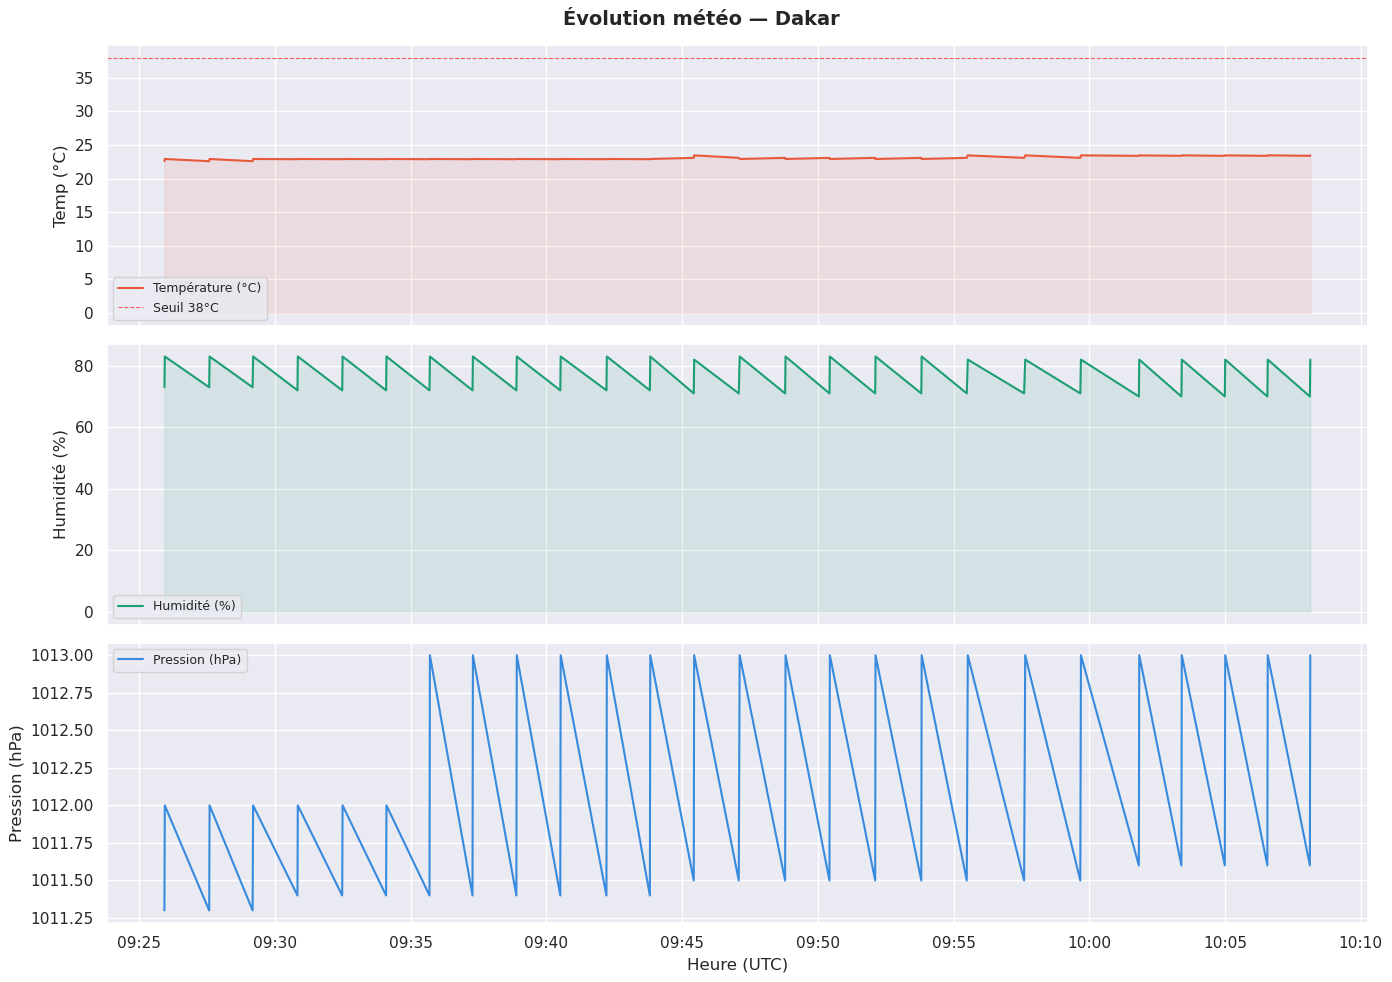

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

# ── PARAMÈTRES ────────────────────────────────────────────────────────────
REGION = 'Dakar'   # change ici : Dakar | Thiès | Saint-Louis | etc.
SEUIL  = 38
# ─────────────────────────────────────────────────────────────────────────

df = df_proc[df_proc['region'] == REGION].copy().sort_values('time')
print(f'{len(df)} points pour {REGION}')

sns.set_theme(style='darkgrid', palette='muted')
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f'Évolution météo — {REGION}', fontsize=14, fontweight='bold')

# Température
axes[0].plot(df['time'], df['temp'].values, color='#E8593C', linewidth=1.5, label='Température (°C)')
axes[0].axhline(SEUIL, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label=f'Seuil {SEUIL}°C')
axes[0].set_ylabel('Temp (°C)')
axes[0].legend(fontsize=9)
axes[0].fill_between(df['time'].values, df['temp'].values, alpha=0.1, color='#E8593C')

# Humidité
axes[1].plot(df['time'], df['hum'].values, color='#1D9E75', linewidth=1.5, label='Humidité (%)')
axes[1].set_ylabel('Humidité (%)')
axes[1].legend(fontsize=9)
axes[1].fill_between(df['time'].values, df['hum'].values, alpha=0.1, color='#1D9E75')

# Pression
if 'pressure' in df.columns and df['pressure'].notna().any():
    axes[2].plot(df['time'], df['pressure'].values, color='#378ADD', linewidth=1.5, label='Pression (hPa)')
    axes[2].set_ylabel('Pression (hPa)')
    axes[2].legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('Heure (UTC)')
plt.tight_layout()
plt.show()

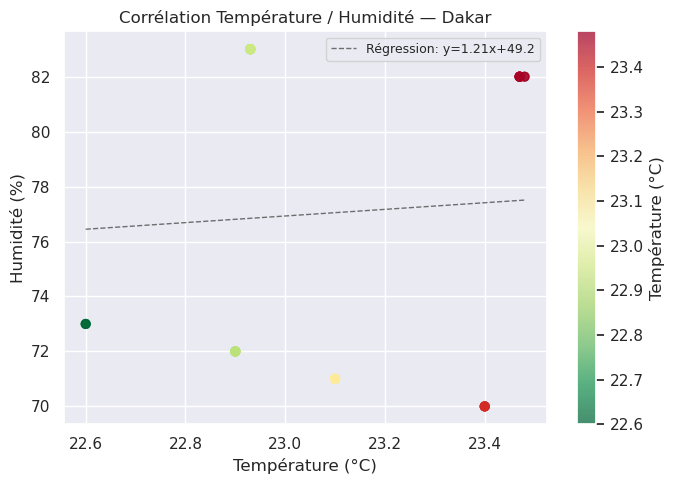

In [36]:
# Corrélation Température / Humidité
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df['temp'].values, df['hum'].values, 
                c=df['temp'].values, cmap='RdYlGn_r', alpha=0.7, s=40)
plt.colorbar(sc, label='Température (°C)')
ax.set_xlabel('Température (°C)')
ax.set_ylabel('Humidité (%)')
ax.set_title(f'Corrélation Température / Humidité — {REGION}')

df_mask = df.dropna(subset=['temp', 'hum'])
if len(df_mask) >= 2:
    coef = np.polyfit(df_mask['temp'].values, df_mask['hum'].values, 1)
    x_line = np.linspace(df_mask['temp'].min(), df_mask['temp'].max(), 100)
    ax.plot(x_line, np.polyval(coef, x_line), 'k--', linewidth=1, alpha=0.6,
            label=f'Régression: y={coef[0]:.2f}x+{coef[1]:.1f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4. Analyse statistique

In [37]:
from scipy import stats

df_clean = df.dropna(subset=['temp', 'hum'])
if len(df_clean) >= 2:
    r, p = stats.pearsonr(df_clean['temp'], df_clean['hum'])
    print(f'Corrélation Pearson (temp/hum) : r = {r:.4f}, p-value = {p:.4f}')
    print(f'  → {"Corrélation significative" if p < 0.05 else "Pas de corrélation significative"} (α=0.05)')
else:
    print(f'⚠️ Pas assez de données pour calculer la corrélation ({len(df_clean)} points)')


Corrélation Pearson (temp/hum) : r = 0.0532, p-value = 0.7082
  → Pas de corrélation significative (α=0.05)


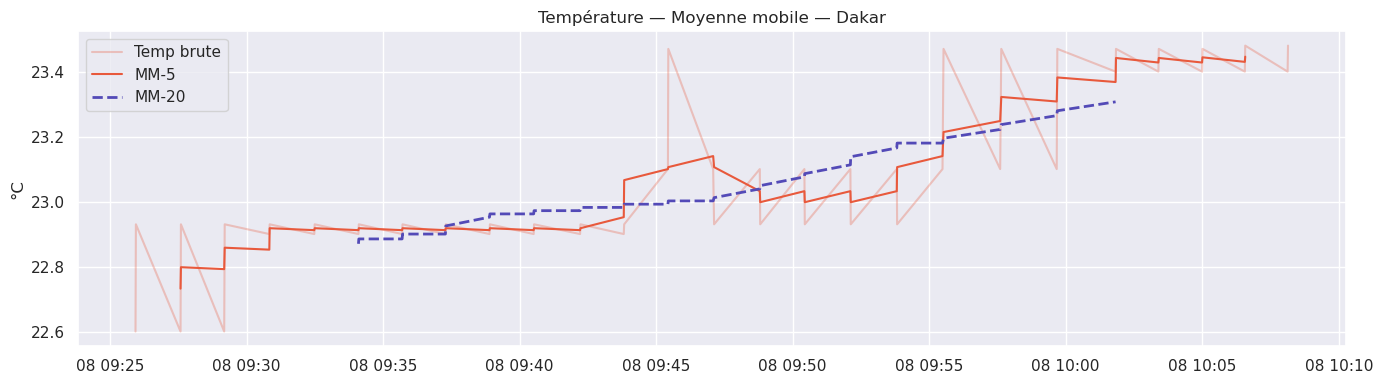

In [38]:
# Moyennes mobiles
df_idx = df.copy().set_index('time').sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_idx.index, df_idx['temp'], alpha=0.3, color='#E8593C', label='Temp brute')

if len(df_idx) >= 5:
    ma5  = df_idx['temp'].rolling(5,  center=True).mean()
    ma20 = df_idx['temp'].rolling(20, center=True).mean()
    ax.plot(df_idx.index, ma5,  color='#E8593C', linewidth=1.5, label='MM-5')
    ax.plot(df_idx.index, ma20, color='#534AB7', linewidth=2,   label='MM-20', linestyle='--')

ax.set_title(f'Température — Moyenne mobile — {REGION}')
ax.set_ylabel('°C')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Comparaison multi-régions


In [41]:
import plotly.express as px

# ── PARAMÈTRES ────────────────────────────────────────────────────────────
REGIONS_A_COMPARER = ['Dakar', 'Saint-Louis', 'Tambacounda', 'Ziguinchor']
VARIABLE_COMP      = 'temp'   # temp | hum | pressure | wind_speed
# ─────────────────────────────────────────────────────────────────────────

df_multi = df_proc[df_proc['region'].isin(REGIONS_A_COMPARER)].sort_values('time')

fig = px.line(df_multi, x='time', y=VARIABLE_COMP, color='region',
              title=f'{VARIABLE_COMP} — comparaison régions', markers=True)
fig.update_layout(template='plotly_dark', height=400)
fig.show()

## 6. Kafka en direct

In [42]:
from kafka import KafkaConsumer
import json

# ── PARAMÈTRES ────────────────────────────────────────────────────────────
N_MESSAGES = 10   # nombre de messages à lire
# ─────────────────────────────────────────────────────────────────────────

print(f'Lecture des {N_MESSAGES} derniers messages Kafka...')
consumer = KafkaConsumer(
    'senegal-meteo',
    bootstrap_servers=['kafka1:9092', 'kafka2:9093', 'kafka3:9094'],
    auto_offset_reset='latest',
    enable_auto_commit=False,
    value_deserializer=lambda b: json.loads(b.decode('utf-8')),
    consumer_timeout_ms=8000,
)

live = []
for msg in consumer:
    live.append(msg.value)
    print(f'  📨 [{msg.value.get("region","?")}] {msg.value.get("temp","?")}°C')
    if len(live) >= N_MESSAGES:
        break

consumer.close()
print(f'\n✅ {len(live)} messages reçus')
if live:
    display(pd.DataFrame(live))

Lecture des 10 derniers messages Kafka...
  📨 [Dakar] 23.47°C
  📨 [Dakar] 23.4°C
  📨 [Thiès] 25.5°C
  📨 [Thiès] 25.08°C
  📨 [Diourbel] 26.8°C
  📨 [Diourbel] 29.13°C
  📨 [Fatick] 26.5°C
  📨 [Fatick] 28.19°C
  📨 [Kaolack] 27.4°C
  📨 [Kaolack] 29°C

✅ 10 messages reçus


,source,time,region,region_code,lat,lon,temp,temp_feels,hum,pressure,wind_speed,wind_dir,weather_code,weather_label
0,openweathermap,2026-05-08T10:13:12.557083+00:00,Dakar,DK,14.6928,-17.4467,23.47,24.01,82,1013.0,4.92,51,803,nuageux
1,open-meteo,2026-05-08T10:13:11.661448+00:00,Dakar,DK,14.6928,-17.4467,23.40,23.20,70,1011.6,20.20,5,0,NaN
2,open-meteo,2026-05-08T10:13:14.486494+00:00,Thiès,TH,14.7886,-16.9255,25.50,25.30,55,1003.8,16.30,349,0,NaN
3,openweathermap,2026-05-08T10:13:14.834952+00:00,Thiès,TH,14.7886,-16.9255,25.08,24.66,39,1012.0,6.96,352,803,nuageux
4,open-meteo,2026-05-08T10:13:17.598538+00:00,Diourbel,DB,14.6554,-16.2322,26.80,26.90,45,1010.8,9.80,352,2,NaN
5,openweathermap,2026-05-08T10:13:18.508238+00:00,Diourbel,DB,14.6554,-16.2322,29.13,27.92,29,1012.0,3.87,4,801,peu nuageux
6,open-meteo,2026-05-08T10:13:20.405164+00:00,Fatick,FK,14.3390,-16.4114,26.50,26.90,48,1011.6,9.20,358,1,NaN
7,openweathermap,2026-05-08T10:13:20.652182+00:00,Fatick,FK,14.3390,-16.4114,28.19,27.39,33,1013.0,3.27,12,800,ciel dégagé
8,open-meteo,2026-05-08T10:13:22.594574+00:00,Kaolack,KL,14.1652,-16.0726,27.40,27.50,42,1011.3,7.90,357,1,NaN
9,openweathermap,2026-05-08T10:13:22.897772+00:00,Kaolack,KL,14.1652,-16.0726,29.00,27.82,29,1013.0,2.91,4,800,ciel dégagé


## 7. Export des résultats

In [43]:
# ── PARAMÈTRES ────────────────────────────────────────────────────────────
NOM_FICHIER = 'analyse_senegal.csv'   # nom du fichier CSV
# ─────────────────────────────────────────────────────────────────────────

# Export CSV local
df_proc.to_csv(NOM_FICHIER, index=False)
print(f'✅ {NOM_FICHIER} exporté localement')

# Upload vers MinIO bucket analytics
analytics_bucket = 'analytics'
if not client.bucket_exists(analytics_bucket):
    client.make_bucket(analytics_bucket)

csv_bytes = df_proc.to_csv(index=False).encode('utf-8')
client.put_object(
    analytics_bucket, f'exports/{NOM_FICHIER}',
    data=io.BytesIO(csv_bytes), length=len(csv_bytes),
    content_type='text/csv'
)
print(f'✅ Uploadé → s3://{analytics_bucket}/exports/{NOM_FICHIER}')

✅ analyse_senegal.csv exporté localement
✅ Uploadé → s3://analytics/exports/analyse_senegal.csv


## 8. Espace libre 🧪
> Ajoute tes propres analyses ici. Voici quelques idées :
> - Comparer deux sources (open-meteo vs openweathermap)
> - Trouver la région la plus chaude / la plus humide
> - Calculer des moyennes horaires ou journalières
> - Détecter des anomalies sur d'autres variables